In [23]:
#Import Libraries
import pandas as pd
import sqlite3
import os
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
# Connect to SQLite Database

In [25]:
conn = sqlite3.connect('expenses.db')
cursor = conn.cursor()

In [26]:
cursor.execute('''
CREATE TABLE IF NOT EXISTS expenses (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    date TEXT,
    category TEXT,
    amount REAL
)
''')
conn.commit()

In [27]:
# CLI Function to Add Expense

In [28]:
def add_expense():
    date = input("Enter date (YYYY-MM-DD) [leave blank for today]: ")
    if date == "":
        date = datetime.now().strftime('%Y-%m-%d')

    category = input("Enter category (Food/Transport/Shopping/Bills/Entertainment): ")
    amount = float(input("Enter amount: "))

    cursor.execute("INSERT INTO expenses (date, category, amount) VALUES (?, ?, ?)",
                   (date, category, amount))
    conn.commit()

    print(" Expense added successfully!")

In [31]:
import random
from datetime import timedelta

def generate_random_data(n=200):
    categories = ['Food', 'Transport', 'Shopping', 'Bills', 'Entertainment']

    for _ in range(n):
        random_days_ago = random.randint(1, 90)
        date = (datetime.now() - timedelta(days=random_days_ago)).strftime('%Y-%m-%d')
        category = random.choice(categories)
        amount = round(random.uniform(50, 2000), 2)

        cursor.execute(
            "INSERT INTO expenses (date, category, amount) VALUES (?, ?, ?)",
            (date, category, amount)
        )

    conn.commit()
    print(f"✅ {n} random records inserted!")

In [32]:
def menu():
    while True:
        print("\n===== Expense Tracker =====")
        print("1. Add Expense")
        print("2. View Last 5 Records")
        print("3. Generate Random Data")
        print("4. Exit")

        choice = input("Enter choice: ")

        if choice == '1':
            add_expense()

        elif choice == '2':
            df = pd.read_sql("SELECT * FROM expenses ORDER BY date DESC LIMIT 5", conn)
            print(df)

        elif choice == '3':
            n = int(input("How many random records to generate? "))
            generate_random_data(n)

        elif choice == '4':
            print("Exiting...")
            break

        else:
            print("❌ Invalid choice")

In [33]:
#### menu()


===== Expense Tracker =====
1. Add Expense
2. View Last 5 Records
3. Generate Random Data
4. Exit


Enter choice:  3
How many random records to generate?  100


✅ 100 random records inserted!

===== Expense Tracker =====
1. Add Expense
2. View Last 5 Records
3. Generate Random Data
4. Exit


Enter choice:  4


Exiting...


In [34]:
# Load Data for Analysis

In [35]:
df = pd.read_sql("SELECT * FROM expenses", conn)

In [36]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M')

In [37]:
df.head()

,id,date,category,amount,month
0,1,2026-05-23,food,180.00,2026-05
1,2,2026-04-27,food,200.00,2026-04
2,3,2026-04-27,shopping,1000.00,2026-04
3,4,2025-10-23,bills,10000.00,2025-10
4,5,2026-04-05,Entertainment,256.64,2026-04


In [38]:
# Basic Analysis

In [39]:
print("Total Spending:", df['amount'].sum())

Total Spending: 115325.9


In [40]:
print("Average Spending:", df['amount'].mean())

Average Spending: 1108.9028846153847


In [42]:
category_spending = df.groupby('category')['amount'].sum().sort_values(ascending=False)

In [44]:
category_spending

category
Bills            27935.95
Food             24015.63
Shopping         19487.19
Entertainment    16305.26
Transport        16201.87
bills            10000.00
shopping          1000.00
food               380.00
Name: amount, dtype: float64

In [43]:
monthly_spending = df.groupby('month')['amount'].sum()

In [45]:
monthly_spending

month
2025-10    10000.00
2026-01     1450.87
2026-02    37915.15
2026-03    40112.04
2026-04    25667.84
2026-05      180.00
Freq: M, Name: amount, dtype: float64

### Visualizations

In [47]:
# Category-wise Spending

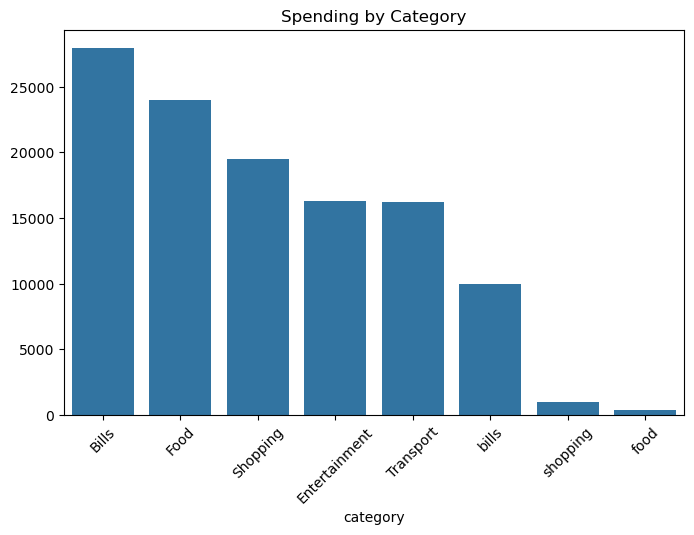

In [48]:
plt.figure(figsize=(8,5))
sns.barplot(x=category_spending.index, y=category_spending.values)
plt.title("Spending by Category")
plt.xticks(rotation=45)
plt.show()

In [49]:
# Monthly Trend

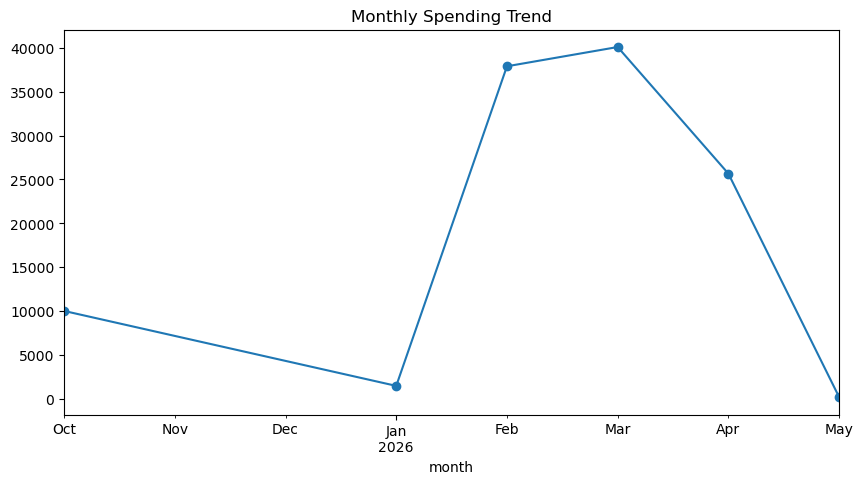

In [50]:
monthly_spending.plot(marker='o', figsize=(10,5))
plt.title("Monthly Spending Trend")
plt.show()

In [51]:
# Distribution

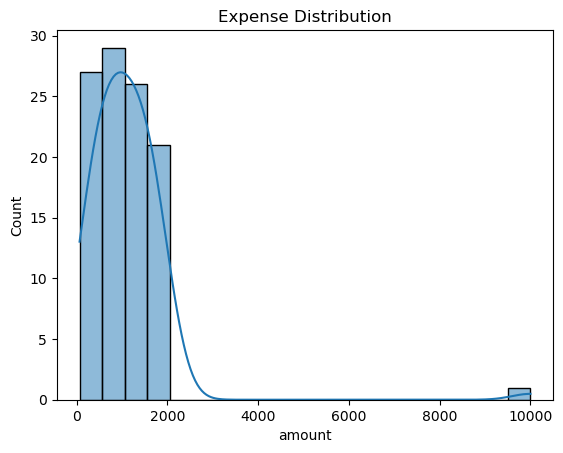

In [52]:
sns.histplot(df['amount'], bins=20, kde=True)
plt.title("Expense Distribution")
plt.show()

In [53]:
df.to_csv('expenses_powerbi.csv', index=False)